# IT5092 Lab 04 — Hodgkin–Huxley vs Leaky Integrate-and-Fire

**Goal:** Implement and compare a reduced neuron model (LIF) with a biophysical conductance-based neuron model (Hodgkin–Huxley).

**You will produce:**
1. LIF baseline + **F–I curve**
2. HH baseline waveform + **gating variables**
3. HH **refractory pulse-gap-pulse** experiment
4. Short comparison paragraph (HH vs LIF)

In [1]:
#Import config + build time axis

import numpy as np
from config import DT, T_TOTAL
t = np.arange(0, T_TOTAL+DT, DT)
print("DT (ms):", DT, "| T_TOTAL (ms):", T_TOTAL, "| Samples:", len(t))

DT (ms): 0.01 | T_TOTAL (ms): 80.0 | Samples: 8001


## Part A — Input current and LIF baseline
We start with a simple step current `I(t)` and simulate a Leaky Integrate-and-Fire neuron.

- LIF integrates membrane potential using a **first-order ODE**
- When the voltage crosses threshold, it is **reset**
- A **refractory period** prevents immediate re-spiking (you will implement this in `lif.py`)

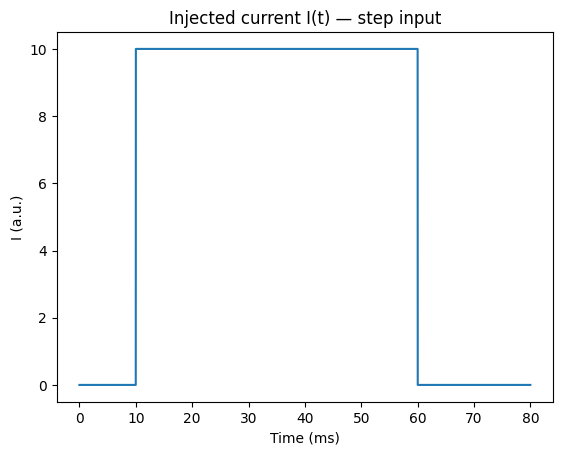

In [2]:
#Build the baseline injected current
import matplotlib.pyplot as plt

from models.input_current import step_current
I = step_current(t, t_on=10, t_off=60, amp=10)

plt.figure()
plt.plot(t, I)
plt.title("Injected current I(t) — step input")
plt.xlabel("Time (ms)")
plt.ylabel("I (a.u.)")
plt.show()

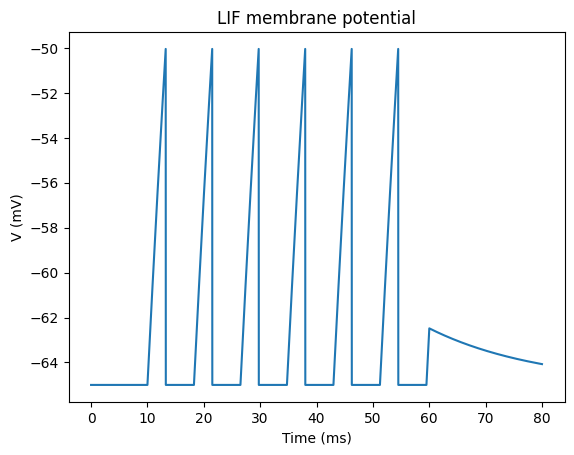

LIF spikes: 6 Rate(Hz): 75.0


In [3]:
#Run LIF baseline
# NOTE: This will fully work only after you complete TODO 1 in models/lif.py

from models.lif import simulate_lif
from utils.plotting import plot_trace
from utils.metrics import firing_rate

V_lif, sp_lif = simulate_lif(I, t)
plot_trace(t, V_lif, "LIF membrane potential", "V (mV)")
print("LIF spikes:", len(sp_lif), "Rate(Hz):", firing_rate(sp_lif, 0, T_TOTAL))

### TODO 5 — LIF F–I curve (in this notebook)

**Goal:** Show how firing rate increases as injected current increases.  
**What you do:**
1. Sweep current amplitude values
2. Run `simulate_lif(...)` for each amplitude
3. Compute firing rate in the *stimulus window* (10–60 ms)
4. Plot firing rate vs amplitude


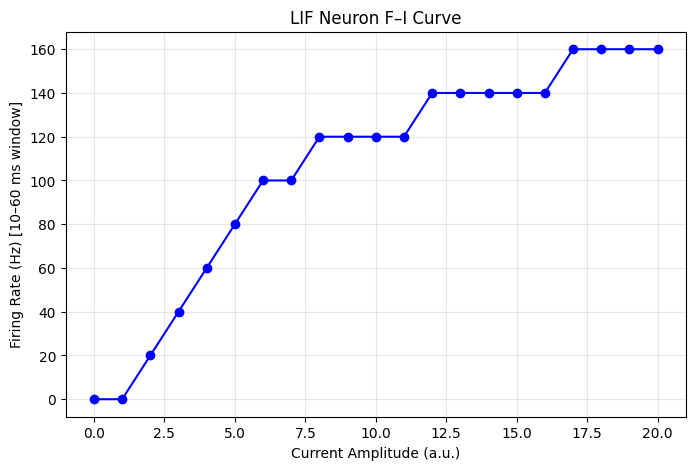

In [4]:
# Cell 5 — TODO 5: LIF F–I curve
# We expand the range to see where spiking actually starts
amps = np.linspace(0, 20, 21)  # Sweep from 0 to 20 with 1 unit steps
rates = []

for amp in amps:
    I_amp = step_current(t, t_on=10.0, t_off=60.0, amp=amp)
    
    V_tmp, sp_tmp = simulate_lif(I_amp, t)
    
    rate_hz = firing_rate(sp_tmp, 10.0, 60.0) 
    rates.append(rate_hz)

plt.figure(figsize=(8, 5))
plt.plot(amps, rates, marker="o", linestyle='-', color='b')
plt.title("LIF Neuron F–I Curve")
plt.xlabel("Current Amplitude (a.u.)")
plt.ylabel("Firing Rate (Hz) [10–60 ms window]")
plt.grid(True, alpha=0.3)
plt.show()


## Part B — Hodgkin–Huxley (HH) baseline

HH is a **conductance-based** neuron model:
- Voltage changes due to ionic currents (Na⁺, K⁺, leak)
- Gating variables (m, h, n) control channel opening/closing
- More biologically realistic than LIF, but computationally heavier

> Your HH model will run only after you complete **TODO 2–4** in `models/hodgkin_huxley.py`.


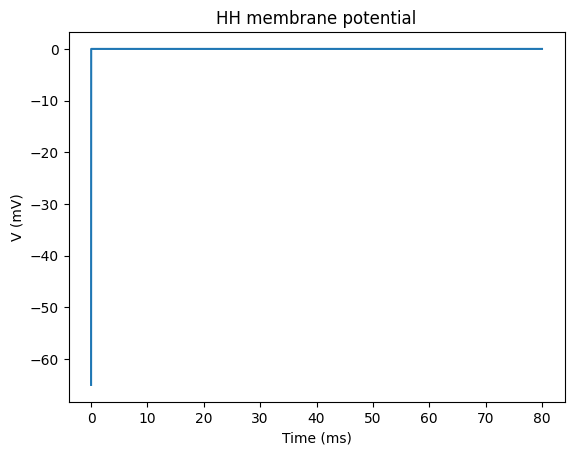

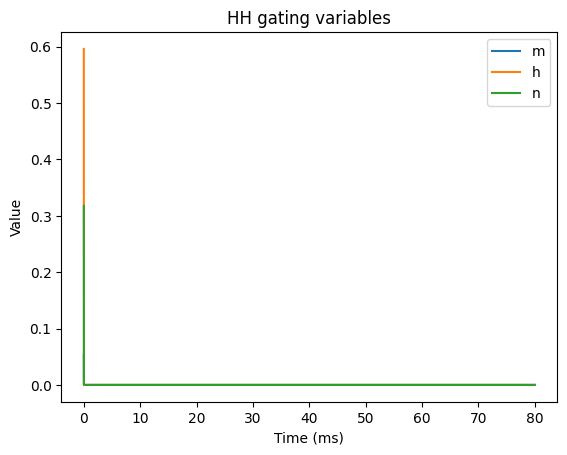

HH spikes: 1
HH rate (Hz) over full trial: 12.5


In [7]:
# Cell 6 — Run HH baseline (requires TODO 2–4 in models/hodgkin_huxley.py)
from models.hodgkin_huxley import simulate_hh
from utils.plotting import plot_hh_gates
from utils.metrics import spike_times_from_threshold

V_hh, m, h, n = simulate_hh(I, t)

plot_trace(t, V_hh, "HH membrane potential", "V (mV)")
plot_hh_gates(t, m, h, n)

sp_hh = spike_times_from_threshold(V_hh, t, thresh=0.0)  # 0 mV upward crossing
print("HH spikes:", len(sp_hh))
print("HH rate (Hz) over full trial:", firing_rate(sp_hh, 0.0, T_TOTAL))

### TODO 6 — HH refractory experiment (pulse–gap–pulse)

**Goal:** Estimate refractory behavior in HH using two brief pulses:
- Pulse 1 evokes a spike
- Pulse 2 may fail if it arrives too soon (refractory)
- Sweep the **gap** between pulses and detect if a second spike occurs

**Expected:** second-spike success increases when the gap becomes large enough.


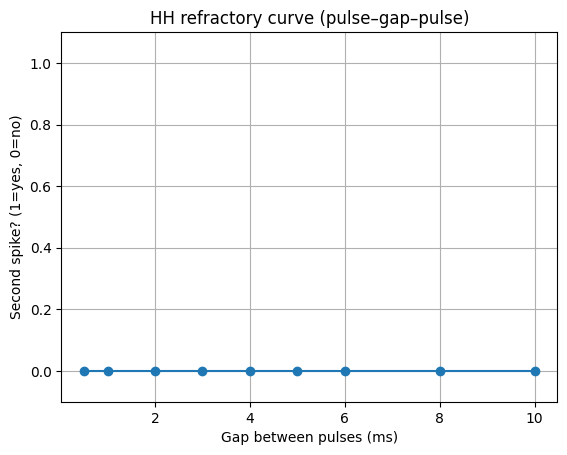

gaps: [0.5, 1, 2, 3, 4, 5, 6, 8, 10]
second spike present: [0, 0, 0, 0, 0, 0, 0, 0, 0]


In [8]:
# Cell 7 — TODO 6: Pulse–gap–pulse refractory curve (HH)
from models.input_current import pulse_train

gaps = [0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # ms (students can modify)
pulse_amp = 20.0                        # adjust if needed
pulse_w = 1.0                           # ms

second_spike_present = []

for g in gaps:
    pulses = [(10.0, 10.0 + pulse_w, pulse_amp), (10.0 + pulse_w + g, 10.0 + 2*pulse_w + g, pulse_amp)]
    I_ref = pulse_train(t, pulses)
    V_ref, m_ref, h_ref, n_ref = simulate_hh(I_ref, t)
    
    # Detect if second spike occurred
    sp = spike_times_from_threshold(V_ref, t, thresh=0.0)
    second_spike_present.append(1 if len(sp) >= 2 else 0)

plt.figure()
plt.plot(gaps, second_spike_present, marker="o")
plt.title("HH refractory curve (pulse–gap–pulse)")
plt.xlabel("Gap between pulses (ms)")
plt.ylabel("Second spike? (1=yes, 0=no)")
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()

print("gaps:", gaps)
print("second spike present:", second_spike_present)


## Part C — HH vs LIF comparison (quantitative + qualitative)

We now compare both models under the same baseline step current.


LIF rate (Hz) [10–60 ms]: 120.0
HH  rate (Hz) [10–60 ms]: 20.0


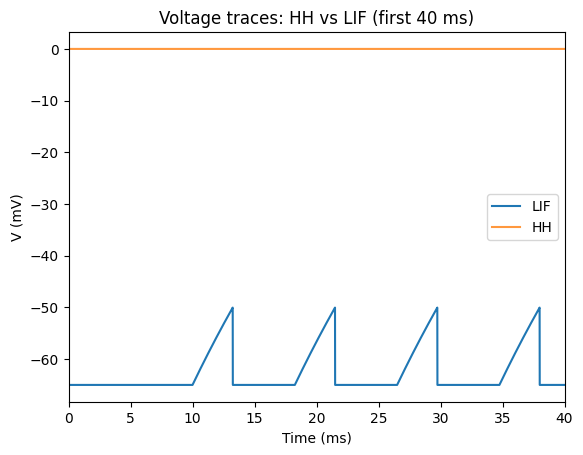

In [9]:
# Cell 8 — Compare HH vs LIF firing rates (stim window) and overlay traces
lif_rate = firing_rate(sp_lif, 10.0, 60.0)
hh_rate  = firing_rate(sp_hh, 10.0, 60.0)

print("LIF rate (Hz) [10–60 ms]:", lif_rate)
print("HH  rate (Hz) [10–60 ms]:", hh_rate)

plt.figure()
plt.plot(t, V_lif, label="LIF")
plt.plot(t, V_hh, label="HH", alpha=0.8)
plt.xlim(0, 40)
plt.title("Voltage traces: HH vs LIF (first 40 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.legend()
plt.show()


### TODO 7 — Short comparison (3–5 sentences)

Write a short scientific-style comparison:

- Which model is more **biophysically realistic**, and why?
- Which model is more **computationally efficient**, and why?
- Compare spike shape: HH waveform vs LIF “threshold-reset” spikes
- Compare how refractory effects appear in each model (HH intrinsic vs LIF implemented rule)


- The Hodgkin-Huxley (HH) model is more biophysically realistic because it explicitly models the non-linear dynamics of ion channels (Sodium and Potassium) using gating variables (m, h, n), whereas the Leaky Integrate-and-Fire (LIF) model is more computationally efficient because it reduces the complex spiking process to a single linear differential equation and a fixed threshold rule. This difference is clearly visible in the spike shape: HH produces a smooth, biologically accurate waveform with a natural after-hyperpolarization, while LIF produces a jagged "sawtooth" profile where the voltage is instantly reset upon hitting a threshold. Furthermore, refractory effects in LIF are enforced by a manual timer ("refractory rule"), but in HH, they emerge intrinsically from the slow recovery of sodium channel inactivation ($h$-gate) and potassium activation ($n$-gate). Consequently, HH is ideal for detailed single-neuron studies, while LIF is preferred for large-scale neural network simulations where speed is critical.